# Edge Online learning for watrer level prediction

In [1]:
# !git clone https://github.com/omardwahba/water_lvl_pred
# import os
# os.chdir('/content/water_lvl_pred/water_lvl_pred')


In [2]:
# pip install -r requirements.txt

In [3]:
# import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

### Training parameter

In [4]:
# --- Define Model Parameters ---
LOOKBACK = 48   # 48 hours of historical data
HORIZON = 24    # 24 hours of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  # we are using batch size of 1 for time series
H_BAR_INDEX = 3 # H_bar is the 4th feature (index 3)
EPSILON = 1e-6  # For numerical stability in normalization



In [5]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by pytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


In [6]:
# --- No-leakage sequences (step = LOOKBACK + HORIZON = 72) ---
x_train_72, y_train_72 = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)
x_test_72,  y_test_72  = uf.create_sequences(test_df.values.astype(np.float32),  LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)

train_ds_72 = uf.RollingNormTimeSeriesDataset(x_train_72, y_train_72, H_BAR_INDEX)
test_ds_72  = uf.RollingNormTimeSeriesDataset(x_test_72,  y_test_72,  H_BAR_INDEX)

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 59112.
Total sequences created: 821
 X shape: (821, 48, 4), y shape: (821, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 17496.
Total sequences created: 243
 X shape: (243, 48, 4), y shape: (243, 24)


## Online Training using ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.011096
   Batch 200/2461, Loss: 0.002191
   Batch 300/2461, Loss: 0.053413
   Batch 400/2461, Loss: 0.047113
   Batch 500/2461, Loss: 0.019306
   Batch 600/2461, Loss: 0.319766
   Batch 700/2461, Loss: 0.033624
   Batch 800/2461, Loss: 0.002608
   Batch 900/2461, Loss: 0.208041
   Batch 1000/2461, Loss: 0.129937
   Batch 1100/2461, Loss: 0.022758
   Batch 1200/2461, Loss: 0.068404
   Batch 1300/2461, Loss: 0.002470
   Batch 1400/2461, Loss: 0.126982
   Batch 1500/2461, Loss: 0.023395
   Batch 1600/2461, Loss: 0.072305
   Batch 1700/2461, Loss: 0.030043
   Batch 1800/2461, Loss: 0.072997
   Batch 1900/2461, Loss: 0.064200
   Batch 2000/2461, Loss: 0.088276
   Batch 2100/2461, Loss: 0.031400
   Batch 2200/2461, Loss: 0.018397
   Batch 2300/2461, Loss: 0.097561
   Batch 2400/2461, Loss: 0.005988
   Batch 2461/2461, Loss: 0.035786
Training complete.


============== FINAL COMPARISON ==============
online-ADAM      

Saved PNG: results/training\Online Learning Training Results.png


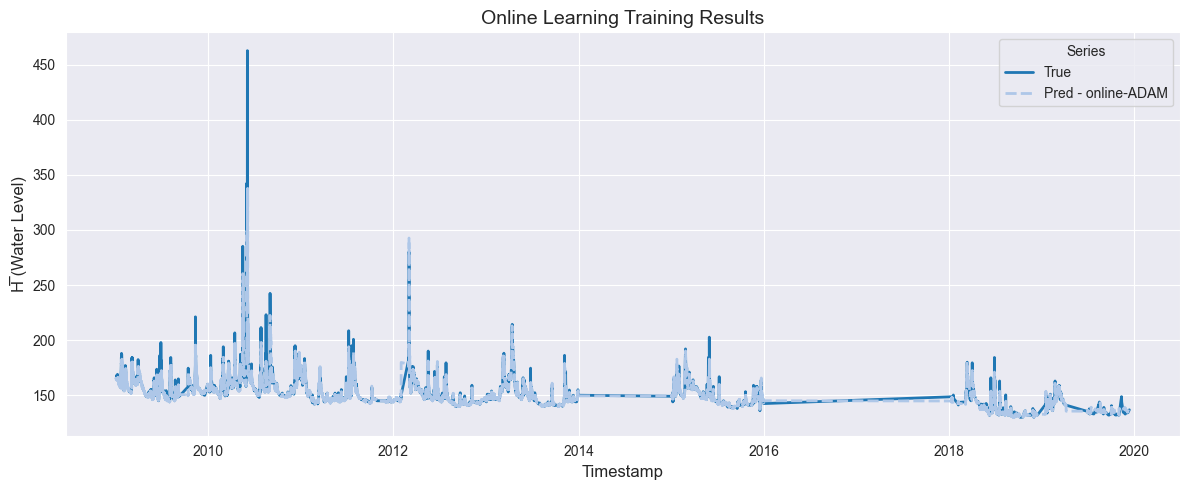

Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [7]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

Testing complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=5.0421 | MAE=1.4225 | R²=0.8077


Saved PNG: results/testing/online\Online Learning MLP test.png


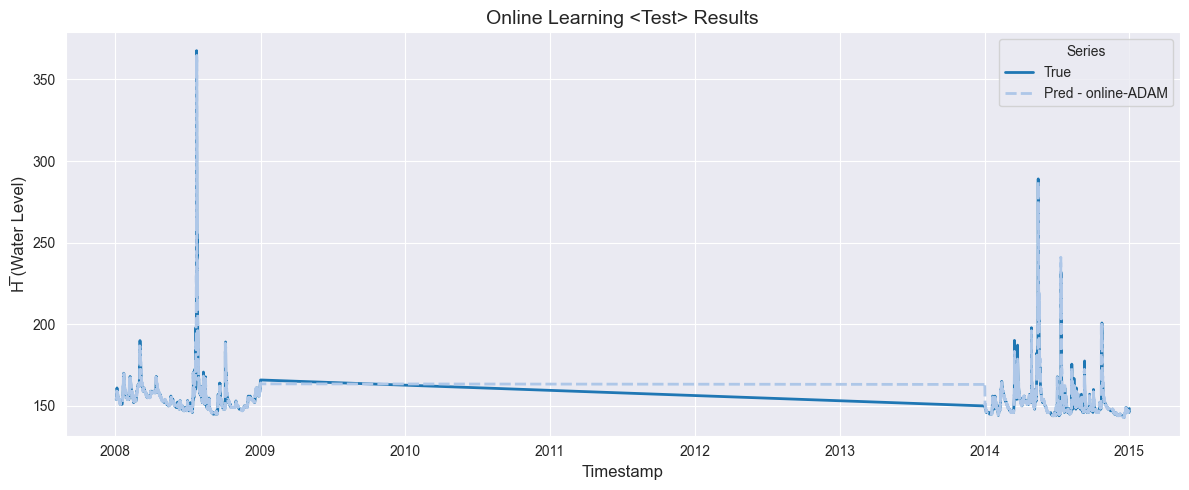

Appended metrics to CSV: results/testing/online\Online Learning MLP test.csv
Exported results to CSV: results/testing/predictions_vs_true/online_MLP.csv


In [8]:
# evaluation on test set
y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
uf.calculate_metrics_and_plot({"online-ADAM": (y_true_test, y_pred_test, time_indices_test)},
                              plot_title = 'Online Learning <Test> Results',
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/testing/online/Online Learning MLP test')
# Save predictions to CSV files to be used later in Experiments
uf.export_results_to_csv({"MLP": (y_true_test, y_pred_test,time_indices_test)}, 
                         "results/testing/predictions_vs_true/online")
    


Starting 'online' training with 821 batches...
   Batch 100/821, Loss: 0.067403
   Batch 200/821, Loss: 0.105721
   Batch 300/821, Loss: 0.014101
   Batch 400/821, Loss: 0.025704
   Batch 500/821, Loss: 0.013484
   Batch 600/821, Loss: 0.042445
   Batch 700/821, Loss: 0.026834
   Batch 800/821, Loss: 0.348180
   Batch 821/821, Loss: 0.087840
Training complete.
Testing complete.


============== FINAL COMPARISON ==============
online-ADAM s24 (original) | RMSE=5.0421 | MAE=1.4225 | R²=0.8077
online-ADAM s72 (no-leak) | RMSE=5.6490 | MAE=1.5536 | R²=0.7574


Saved PNG: results/testing/online\Online_step_comparison.png


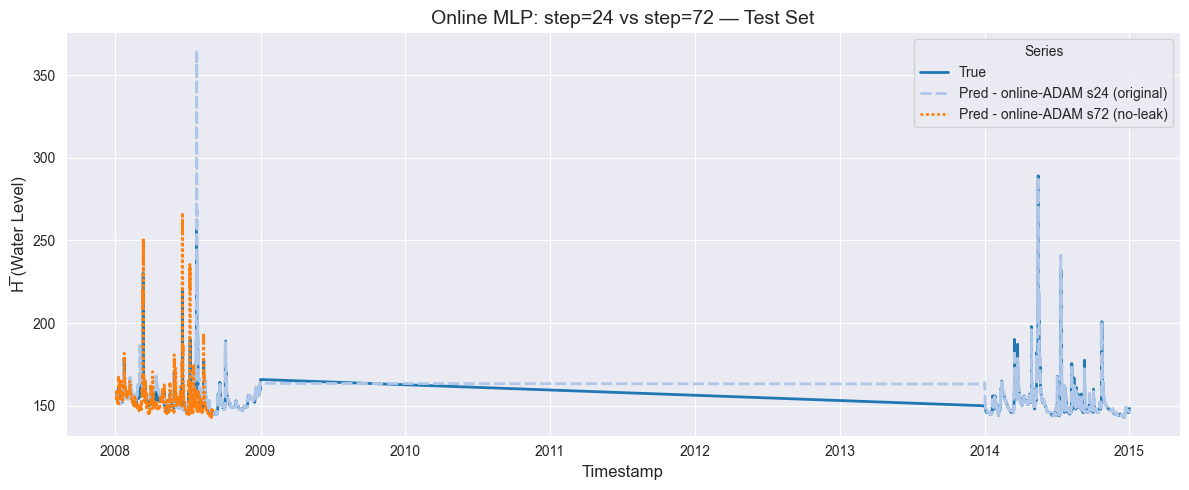

Appended metrics to CSV: results/testing/online\Online_step_comparison.csv


In [9]:
# --- Train & evaluate with step=72 (no leakage) ---
model_72, optimizer_72, criterion_72 = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true_72, y_pred_72, time_indices_72, _ = uf.train_model_online(model_72, optimizer_72, criterion_72,
                                                                   train_ds_72, train_df,
                                                                   LOOKBACK, HORIZON, BATCH_SIZE)

y_true_test_72, y_pred_test_72, time_indices_test_72 = uf.model_evaluate_with_norm(model_72, criterion_72,
                                                                                    test_ds_72, test_df.index,
                                                                                    LOOKBACK, HORIZON, BATCH_SIZE)

# --- Compare step=24 (original) vs step=72 (no leakage) on test set ---
uf.calculate_metrics_and_plot(
    {
        "online-ADAM s24 (original)": (y_true_test,    y_pred_test,    time_indices_test),
        "online-ADAM s72 (no-leak)":  (y_true_test_72, y_pred_test_72, time_indices_test_72),
    },
    plot_title="Online MLP: step=24 vs step=72 — Test Set",
    export_metrics=True,
    export_html=True,
    export_file_name='results/testing/online/Online_step_comparison'
)

## Testing Always updating
See model behaviour if we allowed it to learn on the fly from the testing data.<br>
**conclusion**<br>
Model's performance metrics went up as we all model to optimize and generalize more. In contarst model ability to adapt in lowered.<br>
We need to investigate more about optimizers and the adaptability, generalization trade-off.


Starting 'online' training with 728 batches...
   Batch 100/728, Loss: 0.116852
   Batch 200/728, Loss: 0.155894
   Batch 300/728, Loss: 0.505572
   Batch 400/728, Loss: 0.138649
   Batch 500/728, Loss: 0.005879
   Batch 600/728, Loss: 0.023593
   Batch 700/728, Loss: 0.011336
   Batch 728/728, Loss: 0.156795
Training complete.


============== FINAL COMPARISON ==============
online-MLP           | RMSE=4.3739 | MAE=1.3765 | R²=0.8553


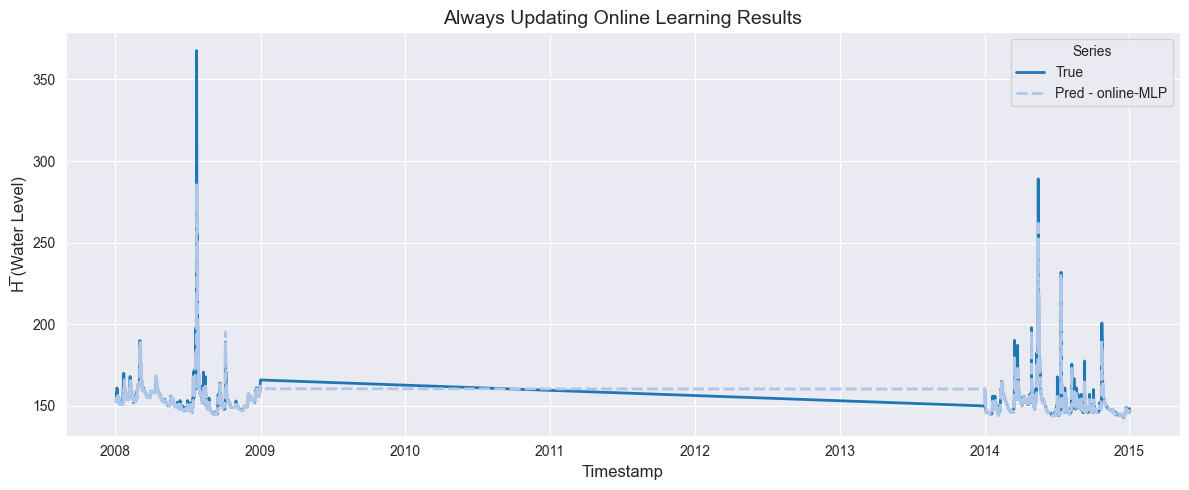

In [10]:
# Testing with always updating 
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              test_ds, test_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-MLP": (y_true, y_pred, time_indices)}, 
                              plot_title="Always Updating Online Learning Results")